In [1]:
import math
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
class Rectangle:
    def __init__(self, x, y, w, h):
        self.x = x
        self.y = y
        self.w = w
        self.h = h

class Circle:
    def __init__(self, x, y, r):
        self.x = x
        self.y = y
        self.r = r

class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

def generate_random_rectangle(reclims, rng):
    x = rng.uniform(reclims[0][0], reclims[0][1])
    y = rng.uniform(reclims[1][0], reclims[1][1])
    w = rng.uniform(reclims[2][0], reclims[2][1])
    h = rng.uniform(reclims[3][0], reclims[3][1])
    return Rectangle(x, y, w, h)

def generate_random_circle(cirlims, rng):
    x = rng.uniform(cirlims[0][0], cirlims[0][1])
    y = rng.uniform(cirlims[1][0], cirlims[1][1])
    r = rng.uniform(cirlims[2][0], cirlims[2][1])
    return Circle(x, y, r)

def generate_random_point(plims, rng):
    x = rng.uniform(plims[0][0], plims[0][1])
    y = rng.uniform(plims[1][0], plims[1][1])
    return Point(x, y)

def check_overlap(rectangle, circle):
    # Calculate the distance between the center of the circle and the center of the rectangle
    dx = abs(circle.x - rectangle.x - rectangle.w / 2)
    dy = abs(circle.y - rectangle.y - rectangle.h / 2)

    if dx > (rectangle.w / 2 + circle.r):
        return False
    if dy > (rectangle.h / 2 + circle.r):
        return False

    return True

def generate_map(reclims, cirlims, plims, seed=0):
    rng = np.random.RandomState(seed)
    while True:
        rectangle = generate_random_rectangle(reclims, rng)
        circle = generate_random_circle(cirlims, rng)
        if not check_overlap(rectangle, circle):
            break

    while True:
        point1 = generate_random_point(plims, rng)
        point2 = generate_random_point(plims, rng)
        point3 = generate_random_point(plims, rng)

        # # set waypoint inside a rectangle defined by start point and terminal point
        # plims_for_wp = [[min(point1.x, point2.x), max(point1.x, point2.x)],
        #                 [min(point1.y, point2.y), max(point1.y, point2.y)]]
        # point3 = generate_random_point(plims_for_wp, rng)
        
        if not ((point1.x >= rectangle.x and point1.x <= rectangle.x + rectangle.w and point1.y >= rectangle.y and point1.y <= rectangle.y + rectangle.h) 
                or (math.sqrt((point1.x - circle.x) ** 2 + (point1.y - circle.y) ** 2) <= circle.r)):
            if not ((point2.x >= rectangle.x and point2.x <= rectangle.x + rectangle.w and point2.y >= rectangle.y and point2.y <= rectangle.y + rectangle.h) 
                    or (math.sqrt((point2.x - circle.x) ** 2 + (point2.y - circle.y) ** 2) <= circle.r)):
                if not ((point3.x >= rectangle.x and point3.x <= rectangle.x + rectangle.w and point3.y >= rectangle.y and point3.y <= rectangle.y + rectangle.h) 
                        or (math.sqrt((point3.x - circle.x) ** 2 + (point3.y - circle.y) ** 2) <= circle.r)):
                    break

    return [rectangle, circle, point1, point2, point3]

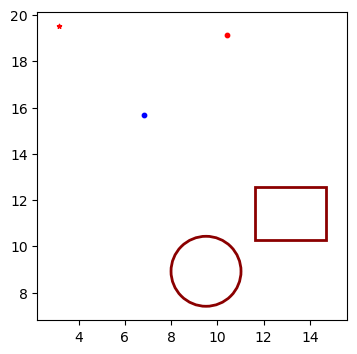

In [4]:
# generate map
reclims = [[3, 15], [3, 15], [1, 4], [1, 4]]
cirlims = [[5, 15], [5, 15], [1, 2]]
plims = [[1,20], [1, 20]]
seed = np.random.randint(0, 100)
nfz_rec, nfz_cir, start, terminal, waypoint = generate_map(reclims, cirlims, plims, seed)

# plot map
fig, ax = plt.subplots(figsize=(4, 4))

# no-fly-zone in rectangle shape
rec = patches.Rectangle((nfz_rec.x, nfz_rec.y), nfz_rec.w, nfz_rec.h, 
                        linewidth=2, edgecolor='darkred', facecolor='none')
ax.add_patch(rec)

# no-fly-zone in circle shape
cir = patches.Circle((nfz_cir.x, nfz_cir.y), nfz_cir.r, 
                     linewidth=2, edgecolor='darkred', facecolor='none')
ax.add_patch(cir)

# start point
plt.scatter(start.x, start.y, s=10, c='r', marker='*')

# terminal point
plt.scatter(terminal.x, terminal.y, s=10, c='r', marker='o')

# waypoint
plt.scatter(waypoint.x, waypoint.y, s=10, c='b')
    
ax.axis("equal")
plt.show()

In [3]:
# parameters not to change
T = 35
dim_state = 4
dim_control = 2
N_control = 6
N_nfz = 6
H = 1e5
epsilon = 1e-5
delta_t = 0.1
matrix_A = np.vstack((np.hstack((np.eye(dim_control), delta_t*np.eye(dim_control))),np.hstack((np.zeros((dim_control,dim_control)), np.eye(dim_control)))))
matrix_B = np.vstack((1/2*delta_t**2*np.eye(dim_control),delta_t*np.eye(dim_control)))

num_of_nfz_polygon = 1
num_of_nfz_circle = 1
num_of_wp = 1

reclims = [[3, 15], [3, 15], [2, 5], [2, 5]]
cirlims = [[5, 15], [5, 15], [1, 2]]
plims = [[2,18], [2, 18]]

In [4]:
def g(c_nfz, index):
    m = c_nfz.shape[0]
    g_index = np.sign((c_nfz[(index+1)%m,0]-c_nfz[index%m,0])*(c_nfz[(index+2)%m,1]-c_nfz[index%m,1])
                      -(c_nfz[(index+1)%m,1]-c_nfz[index%m,1])*(c_nfz[(index+2)%m,0]-c_nfz[index%m,0]))
    return g_index

In [5]:
def generate_instance(ins_num, rng):
    for ins in range(ins_num):
        # randomly generate limitation for velocity and acceleration
        v_max = rng.uniform(17.5, 22.5)
        a_max = rng.uniform(2.5, 3.5)

        # randomly generate map
        # note that generate_map() gets extended rectangle non-fly-zone
        seed = rng.randint(10000)
        nfz_rec_extend, nfz_cir, start, terminal, waypoint = generate_map(reclims, cirlims, plims, seed)
        
        # create the model 
        model = gp.Model() 
        
        # add variables
        x = model.addMVar((dim_state, T + 1), lb=-GRB.INFINITY, vtype=GRB.CONTINUOUS, name="states")
        u = model.addMVar((dim_control, T), lb=-GRB.INFINITY, vtype=GRB.CONTINUOUS, name="controls")
        b_nfz_polygon = {}
        for c in range(0, num_of_nfz_polygon):
            b_nfz_polygon[c] = model.addMVar((4, T+1), vtype=GRB.BINARY, name="nfz_polygon")
        b_nfz_circle = model.addMVar((num_of_nfz_circle, N_nfz, T+1), vtype=GRB.BINARY, name="nfz_circle")
        b_wp = model.addMVar((num_of_wp, T + 1), vtype=GRB.BINARY, name="wp")
        b_f = model.addMVar(T + 1, vtype=GRB.BINARY, name="final")

        # set objective function
        model.setObjective(gp.quicksum(i * b_f[i] for i in range(0, T + 1)), GRB.MINIMIZE)

        # add constraints
        # start point
        model.addConstr(x[0,0] - start.x == 0, name='sx')
        model.addConstr(x[1,0] - start.y == 0, name='sy')

        # dynamics
        for i in range(0, T):
            model.addConstr(x[:,i+1]==matrix_A@x[:,i]+matrix_B@u[:,i], name=f"type1_{i}")

        # limits for velocity and acceleartion
        for i in range(0, T + 1):
            for n in range(0, N_control):
                model.addConstr(x[2,i]*math.cos(2*math.pi*n/N_control) + x[3,i]*math.sin(2*math.pi*n/N_control)
                                <=v_max*math.cos(math.pi/N_control), name=f"type21_{n}_{i}")
        for i in range(0, T):
            for n in range(0, N_control):
                model.addConstr(u[0,i]*math.cos(2*math.pi*n/N_control) + u[1,i]*math.sin(2*math.pi*n/N_control)
                                <=a_max*math.cos(math.pi/N_control), name=f"type22_{n}_{i}")
        
        # no-fly-zone
        # rectangle zone
        c_nfz_polygon_extend = np.array([[[nfz_rec_extend.x, nfz_rec_extend.y],
                                          [nfz_rec_extend.x, nfz_rec_extend.y + nfz_rec_extend.h],
                                          [nfz_rec_extend.x + nfz_rec_extend.w, nfz_rec_extend.y + nfz_rec_extend.h],
                                          [nfz_rec_extend.x + nfz_rec_extend.w, nfz_rec_extend.y]]])
        for i in range(0, T + 1):
            for c in range(0, num_of_nfz_polygon):
                c_nfz = c_nfz_polygon_extend[c]
                M = c_nfz.shape[0]
                for m in range(0, M):
                    model.addConstr(g(c_nfz, m)*((c_nfz[(m+1)%M,0]-c_nfz[m%M,0])*(x[1,i]-c_nfz[m%M,1])
                                                -(c_nfz[(m+1)%M,1]-c_nfz[m%M,1])*(x[0,i]-c_nfz[m%M,0]))
                                                <=H*b_nfz_polygon[c][m,i]-epsilon, name=f"type311_{i}_{c}_{m}")
                model.addConstr(sum(b_nfz_polygon[c][:,i])<=M-1, name=f"type312_{i}_{c}")

        # circle zone
        for i in range(0, T + 1):
            for c in range(0, num_of_nfz_circle):
                for n in range(0, N_nfz):
                    model.addConstr(-x[0,i]*math.cos(2*math.pi*n/N_nfz) - x[1,i]*math.sin(2*math.pi*n/N_nfz)
                                    <=-nfz_cir.x*math.cos(2*math.pi*n/N_nfz)-nfz_cir.y*math.sin(2*math.pi*n/N_nfz)-nfz_cir.r + H*b_nfz_circle[c,n,i], 
                                    name=f"type321_{i}_{c}_{n}")
                model.addConstr(sum(b_nfz_circle[c,j,i] for j in range(0, N_nfz)) <= N_nfz-1, name=f"type322_{i}_{c}")

        # waypoint
        for i in range(0, T + 1):
            for w in range(0, num_of_wp):
                model.addConstr(x[0,i]-waypoint.x <= H*(1-b_wp[w, i]), name=f"type41_{w}_{i}")
                model.addConstr(-x[0,i]+waypoint.x <= H*(1-b_wp[w, i]), name=f"type42_{w}_{i}")
                model.addConstr(x[1,i]-waypoint.y <= H*(1-b_wp[w, i]), name=f"type43_{w}_{i}")
                model.addConstr(-x[1,i]+waypoint.y <= H*(1-b_wp[w, i]), name=f"type44_{w}_{i}")
                model.addConstr(sum(b_wp[w, j] for j in range(0,T+1))==1, name=f"type45_{w}_{i}")
            # no use in our case
            for w in range(0, num_of_wp-1):
                model.addConstr(sum(j*b_wp[w, j] for j in range(0,T+1))<=sum(j*b_wp[w+1, j] for j in range(0,T+1))-1)

        # terminal point
        for i in range(0, T + 1):
            model.addConstr(x[0,i]-terminal.x <= H*(1-b_f[i]), name=f"tx1_{i}")
            model.addConstr(-x[0,i]+terminal.x <= H*(1-b_f[i]), name=f"tx2_{i}")
            model.addConstr(x[1,i]-terminal.y <= H*(1-b_f[i]), name=f"ty1_{i}")
            model.addConstr(-x[1,i]+terminal.y <= H*(1-b_f[i]), name=f"ty2_{i}")
            model.addConstr(sum(b_f[j] for j in range(0,T+1))==1, name=f"t1_{i}")
            if num_of_wp > 0:
                model.addConstr(sum(j*b_wp[num_of_wp-1, j] for j in range(0,T+1))<=sum(j*b_f[j] for j in range(0,T+1))-1, name=f"t2_{i}")

        model.write(f"instance_{ins + 1}.mps")


        # this is for test
        num_vars = model.NumVars
        num_constrs = model.NumConstrs
        print("Number of variables:", num_vars)
        print("Number of constraints:", num_constrs)

        print(v_max)
        print(a_max)
        print([start.x, start.y])
        print([terminal.x, terminal.y])
        print([waypoint.x, waypoint.y])
        print([nfz_cir.x, nfz_cir.y, nfz_cir.r])

        # solve the problem
        model.optimize()

        x_sol = (x.X).copy()

        # plot the result
        fig, ax = plt.subplots(figsize=(4, 4))

        # no-fly-zone in rectangle shape
        extend = math.sqrt(2)/4 * v_max * delta_t
        nfz_rec = Rectangle(nfz_rec_extend.x + extend, nfz_rec_extend.y + extend,
                            nfz_rec_extend.w - extend * 2, nfz_rec_extend.h - extend * 2)
        
        print([[nfz_rec.x, nfz_rec.y],
               [nfz_rec.x, nfz_rec.y + nfz_rec.h],
               [nfz_rec.x + nfz_rec.w, nfz_rec.y + nfz_rec.h],
               [nfz_rec.x + nfz_rec.w, nfz_rec.y]])

        rec = patches.Rectangle((nfz_rec.x, nfz_rec.y), nfz_rec.w, nfz_rec.h, 
                                linewidth=2, edgecolor='darkred', facecolor='none')
        ax.add_patch(rec)

        # no-fly-zone in circle shape
        cir = patches.Circle((nfz_cir.x, nfz_cir.y), nfz_cir.r, 
                            linewidth=2, edgecolor='darkred', facecolor='none')
        ax.add_patch(cir)

        t_f = np.where((b_f.X).copy()==1)[0][0]

        # start point
        plt.scatter(x_sol[0,0],x_sol[1,0], s=10, c='r', marker='*')

        # trajectory
        plt.scatter(x_sol[0,1:t_f],x_sol[1,1:t_f], s=2, c='k')

        # terminal point
        plt.scatter(x_sol[0,t_f],x_sol[1,t_f], s=10, c='r', marker='o')

        # waypoint
        plt.scatter(waypoint.x, waypoint.y, s=10, c='b')
            
        ax.axis("equal")
        plt.show()
        


Restricted license - for non-production use only - expires 2024-10-28
Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored
Number of variables: 646
Number of constraints: 1396
20.109578582501275
3.199406367014664
[3.0000160153705426, 2.6875204559682135]
[13.935742985645222, 15.817849961788252]
[12.465961897693266, 10.344914755483002]
[10.242085499523181, 11.952485271551563, 1.241765290611189]
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel(R) Xeon(R) Gold 6348 CPU @ 2.60GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 56 physical cores, 112 logical processors, using up to 32 threads

Optimize a model with 1396 rows, 646 columns and 8114 nonzeros
Model fingerprint: 0xdd5abdd8
Variable types: 214 continuous, 432 integer (432 binary)
Coefficient statistics:
  Matrix range     [5e-03, 1e+05]
  Objective range  [1e+00, 4e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+05]
Presolve removed 448 rows and 74 col

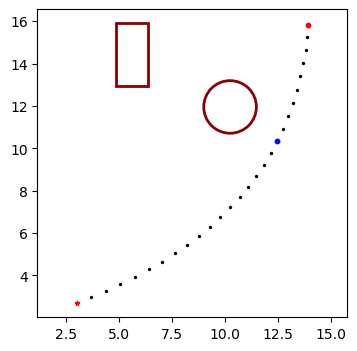

In [6]:
# generate
ins_num = 1

# perfect test instance, keep it
# seed = 9001
seed = 80
rng = np.random.RandomState(seed)
generate_instance(ins_num, rng)